In [1]:
# asyncpg: 비동기, httpx: 외부 API(http)비동기 호출
%pip install asyncpg httpx python-dotenv
%pip install requests


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# TODO: 확인해보니까 플스방 이런건 안불러와졌던데 카카오 API 불러오는 카테고리 종류 확인 먼저 하고 정리해보는게 좋을듯.

In [4]:
# 테스트용 초기 state 만들기
from state import TravelState, UserInput, Place, make_initial_state
from constants.mocks import mock_user_input

initial_state = make_initial_state(mock_user_input)

In [5]:
# [노드] validate_input
# 사용자 입력 -> 좌표 변환, 식사 시간 계산 (전처리)
from nodes.validate_input import validate_input

result = validate_input(initial_state)

print("validate_input 결과:", result)


validate_input 결과: {'user_input': {'location': '홍대역', 'party_size': 2, 'party_type': '연인', 'genders': '혼성', 'age_group': '20대', 'duration': '당일', 'mood_preferences': ['활기찬', '힐링', '이색'], 'activity_preferences': ['카페', '게임/보드게임', '동물 체험', '액티비티'], 'trip_date': '2026-04-24', 'start_time': '10:00', 'end_time': '19:00', 'total_hours': 8.0, 'center_lat': 37.5568707448873, 'center_lng': 126.923778562273, 'search_radius_km': 1.5, 'needs_meal': True, 'meal_times': ['12:30', '18:30'], 'final_keywords': ['카페', '게임/보드게임', '동물 체험', '액티비티', 'pc방', '맛집']}, 'errors': [], 'warnings': [], 'step': 'validated'}


In [6]:
# [노드] fetch_candidates
# kakao Local API로 raw 후보 풀 수집 ( ~200) + PostgreSQL
from nodes.fetch_candidates import fetch_candidates

In [7]:
# LangGraph 그래프 빌드
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(TravelState)

# 노드 등록
graph_builder.add_node("validate_input", validate_input)
graph_builder.add_node("fetch_candidates", fetch_candidates)

# 엣지 (직선 연결)
graph_builder.add_edge(START, "validate_input")
graph_builder.add_edge("validate_input", "fetch_candidates")
graph_builder.add_edge("fetch_candidates", END)

graph = graph_builder.compile()

In [8]:
# 그래프 실행
state_v1 = await graph.ainvoke(initial_state)

print(f"📍 위치: {state_v1['user_input']['location']}")
print(f"📌 좌표: ({state_v1['user_input']['center_lat']}, {state_v1['user_input']['center_lng']})")
print(f"🔍 Kakao raw 후보: {len(state_v1['candidates'])}개")
print(f"⚠️  warnings: {state_v1['warnings']}")
print(f"❌ errors: {state_v1['errors']}")
print(f"✅ step: {state_v1['step']}\n")

print("=== 후보 샘플 (상위 5개) ===")
for p in state_v1["candidates"][:5]:
    print(
        f"  [{p.get('category_group_code', '기타')}] {p['name']} - "
        f"{p.get('road_address_name') or p.get('address_name', '')}"
    )

📍 위치: 홍대역
📌 좌표: (37.5568707448873, 126.923778562273)
🔍 Kakao raw 후보: 397개
⚠️  warnings: []
❌ errors: []
✅ step: fetched

=== 후보 샘플 (상위 5개) ===
  [CE7] 이미커피 - 서울 마포구 동교로25길 7
  [CE7] 디저트 머라이언 - 서울 마포구 와우산로27길 75
  [CE7] 카페장쌤 - 서울 마포구 와우산로29마길 5
  [CE7] 공상온도 - 서울 마포구 동교로23길 40
  [CE7] 카페공명 연남점 - 서울 마포구 연희로 11


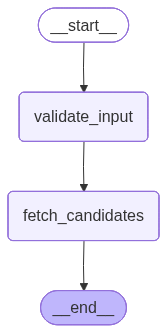

In [9]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))